In [4]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

print(df)
df.head()

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID         Country  
0      

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [11]:
# Create Revenue Column
df['Revenue'] = df['Quantity'] * df['UnitPrice'] 

In [12]:
# Convert InvoiceDate to Datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
#QUESTION 1
#CEO wants Monthly Revenue Trend for 2011

In [15]:
#filter 2011 data
df_2011 = df[df['InvoiceDate'].dt.year == 2011] 

In [21]:
#Create Month Column
df_2011 = df_2011.copy()

df_2011['Month'] = df_2011['InvoiceDate'].dt.month

In [22]:
monthly_revenue = df_2011.groupby('Month')['Revenue'].sum()

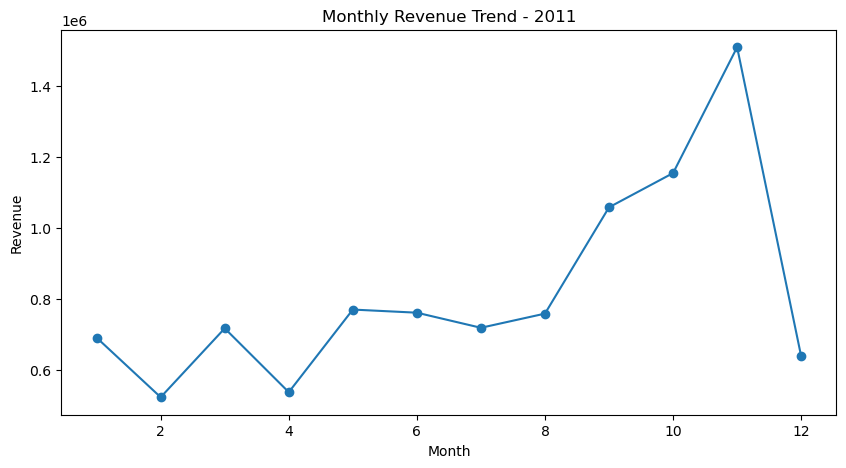

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

monthly_revenue.plot(kind='line', marker='o')

plt.title('Monthly Revenue Trend - 2011')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [25]:
# Remove United Kingdom

country_data = df[df['Country'] != 'United Kingdom'] 

In [26]:
top_countries = country_data.groupby('Country').agg({
    'Revenue':'sum',
    'Quantity':'sum'
}).reset_index()

In [27]:
top_countries = top_countries.sort_values(by='Revenue', ascending=False).head(10)

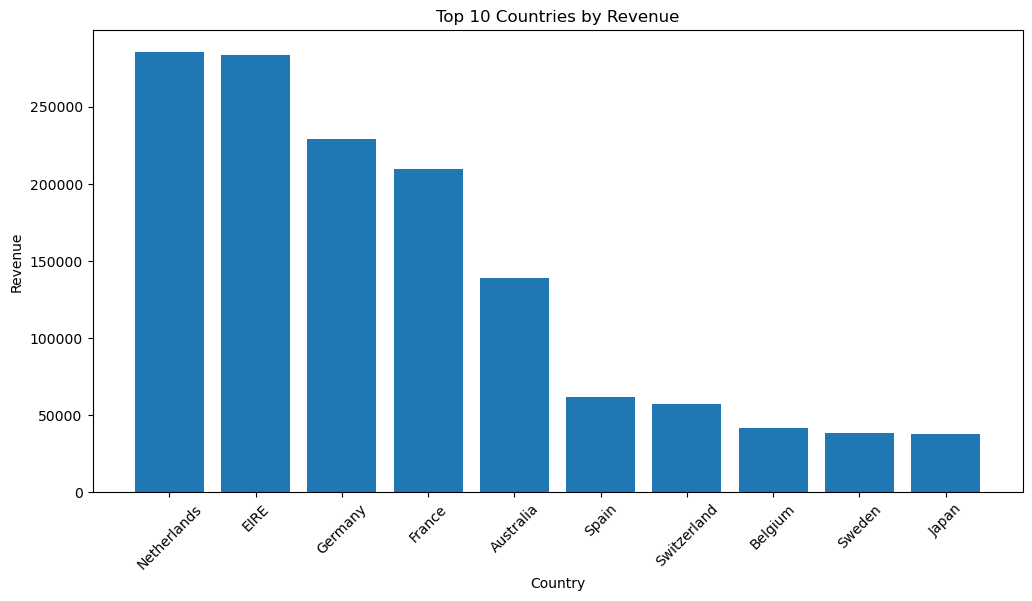

In [28]:
plt.figure(figsize=(12,6))

plt.bar(top_countries['Country'], top_countries['Revenue'])

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [29]:
# QUESTION 3

#Top 10 Customers by Revenue

In [30]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().reset_index()

In [31]:
top_customers = top_customers.sort_values(by='Revenue', ascending=False).head(10)

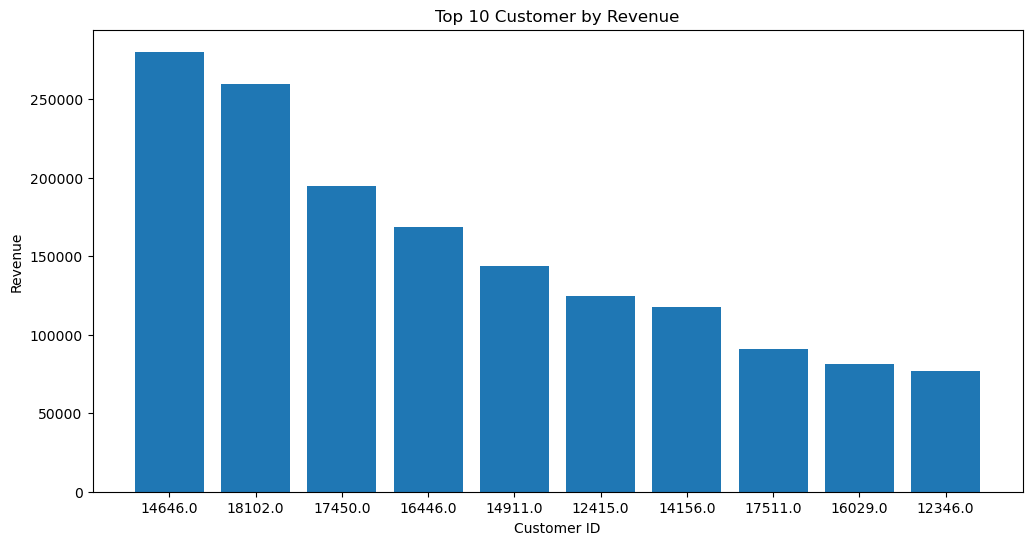

In [33]:
plt.figure(figsize=(12,6))

plt.bar(top_customers['CustomerID'].astype(str),
        top_customers['Revenue'])

plt.title('Top 10 Customer by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.show()

In [ ]:
#Question 4
# Demand by Country (UK not consider)

In [34]:
demand_data = country_data.groupby('Country')['Quantity'].sum().reset_index()

In [35]:
demand_data = demand_data.sort_values(by='Quantity', ascending=False)

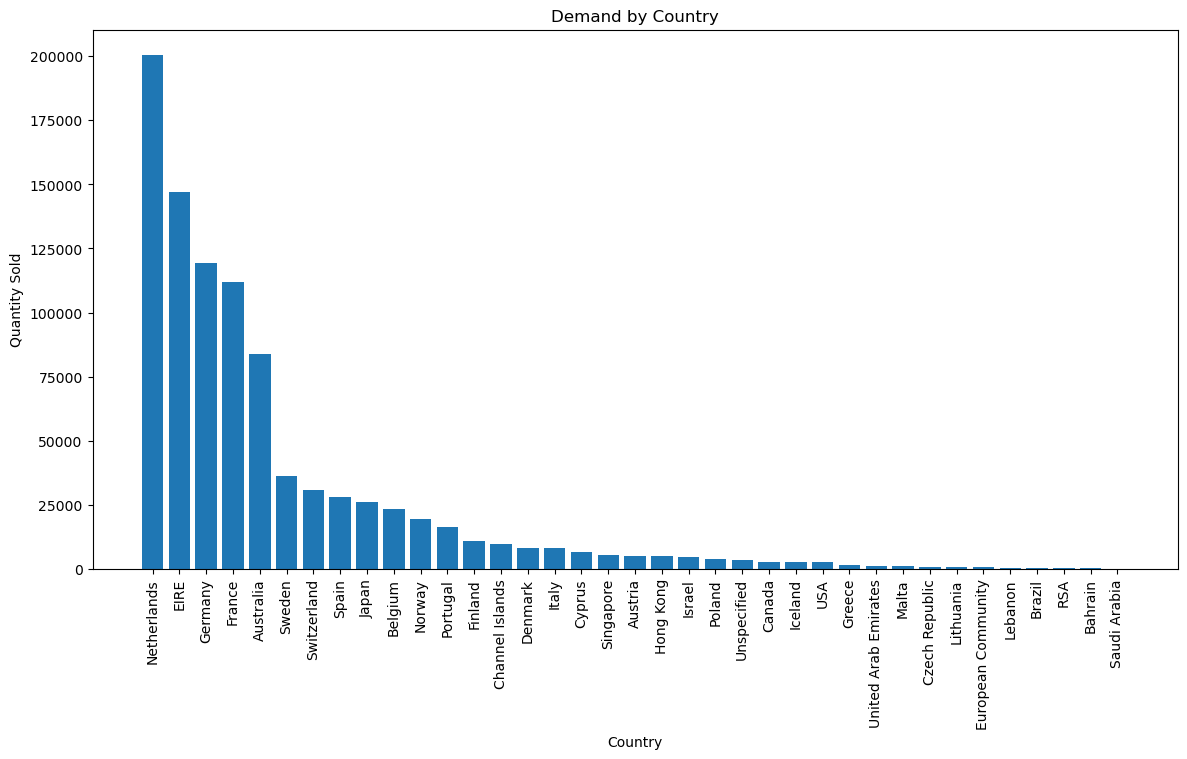

In [36]:
plt.figure(figsize=(14,7))

plt.bar(demand_data['Country'],
        demand_data['Quantity'])

plt.title('Demand by Country')
plt.xlabel('Country')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=90)

plt.show()

In [43]:
#Save Cleaned Dataset
df.to_csv("Cleared_Online_Retail.csv", index=False)
